In [1]:
from neuron import h
import matplotlib.pyplot as plt
import numpy as np
import plotly
import matplotlib
import pandas as pd
import plotly.graph_objects as go

In [2]:
h.load_file("main.hoc")
h.load_file("add_random_synapses.hoc")

	1 
	1 
	1 
	1 
	0 
	1 
23 
	1 
	1 
After any change to cell geometry or nseg, be sure to invoke setpointers()
	1 
	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
Use setstim(DEL, DUR, F0, F1, AMP, PHASE) to change latency (ms), duration (ms),
start and end frequency (Hz), amplitude (V/m) and phase (degrees) of applied
electrical field.
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
	1 
	1 
	0 
	0 
	0 
	0 
	0 
	0 
	42 
	34.521743 
	3.743725e+09 
	0.14110872 
	6.474704e+08 
	41.286144 
Inserting synapse 1 
Randomly selected apical dendrite: 37 
Randomly selected location: 0.10085806 
Randomly determined distance to soma: 278.28887 
The synapse will receive input at 158 ms

Inserting synapse 2 
Randomly selected apical dendrite: 13 
Randomly selected location: 0.064537826 
Randomly determined distance to soma: 134.10369 
The synapse will receive input at 120 ms

Inserting synapse 3 
Randomly selected apical dendrite: 20 
Randomly selected location: 0.77500328 
Randomly determined distance to soma: 255.8465 
Th

1.0

# Electric field direction

Same as before, this stimulation protocol tests what is the minimum strength of the electric field to elicit action potentials in the neuron. Now we perform the stimulation for a single carrier frequency (1 kHz) and a single target frequency (10 Hz), and change the orientation of the electric field.

In [3]:
carrier = 1000 # Hz
target = 10 # Hz

angles = np.arange(1, 361, 10)

In [4]:
def set_stimulus(delay = 100, duration = 900, frequency1 = 1000, frequency2 = 1005, amplitude = 100, phase = 0):
    h.setstim(delay, duration, frequency1, frequency2, amplitude, phase)

In [5]:
def run(tstop = 100, delay = 100, duration = 900, frequency1 = 1000, frequency2 = 1005, amplitude = 100, phase = 0):
    # Set stimulation time
    h.tstop = tstop

    # Setup for recording membrane potential in the soma and time
    soma_v = h.Vector().record(h.soma[0](0.5)._ref_v)
    t = h.Vector().record(h._ref_t)

    set_stimulus(
        delay = delay,
        duration = duration,
        frequency1 = frequency1,
        frequency2 = frequency2,
        amplitude = amplitude,
        phase = phase
    )

    h.run()

    return pd.DataFrame({
        "Time": t,
        "Voltage": soma_v
    })

In [6]:
def has_ap(carrier, target_frequency, amplitude, ap_threshold = -30):
    stim_res = run(
        tstop = 100,
        delay = 0,
        duration = 100,
        frequency1 = carrier,
        frequency2 = carrier + target_frequency,
        amplitude = amplitude,
        phase = 0
    )

    return np.any(stim_res.Voltage >= ap_threshold)

In [7]:
def find_ef_amplitude(carrier, target, initial_amplitude = 1000, ap_threshold = -30, epsilon = 1):
    amplitude = initial_amplitude
    amplitude_step = amplitude / 2
    last_amplitude = initial_amplitude * 2

    while abs(last_amplitude - amplitude) > epsilon:
        last_amplitude = amplitude

        if has_ap(carrier, target, amplitude, ap_threshold = ap_threshold):
            amplitude -= amplitude_step
        else:
            amplitude += amplitude_step

        amplitude_step = amplitude_step / 2

    return amplitude

In [8]:
angle_grid_x, angle_grid_y = np.meshgrid(angles, angles)
ef_strength = np.zeros_like(angle_grid_x)

print(f"Estimated number of simulations: {ef_strength.size}")

Estimated number of simulations: 1296


In [9]:
res = []
for i, theta in enumerate(angles):
    for j, phi in enumerate(angles):
        print(f"Starting stimulation with theta = {theta} and phi = {phi}")
        h.changefield(theta, phi, 100)
    
        amplitude = find_ef_amplitude(carrier, target, initial_amplitude = 300)
        print(f"Amplitude: {amplitude}")

        res.append(pd.DataFrame({
            "Theta": [theta],
            "Phi": [phi],
            "Amplitude": [amplitude]
        }))

        ef_strength[i, j] = amplitude

res = pd.concat(res)
res.reset_index(drop = True, inplace = True)

Starting stimulation with theta = 1 and phi = 1
Amplitude: 362.6953125
Starting stimulation with theta = 1 and phi = 11
Amplitude: 339.2578125
Starting stimulation with theta = 1 and phi = 21
Amplitude: 324.0234375
Starting stimulation with theta = 1 and phi = 31
Amplitude: 272.4609375
Starting stimulation with theta = 1 and phi = 41
Amplitude: 238.4765625
Starting stimulation with theta = 1 and phi = 51
Amplitude: 218.5546875
Starting stimulation with theta = 1 and phi = 61
Amplitude: 203.3203125
Starting stimulation with theta = 1 and phi = 71
Amplitude: 192.7734375
Starting stimulation with theta = 1 and phi = 81
Amplitude: 181.0546875
Starting stimulation with theta = 1 and phi = 91
Amplitude: 172.8515625
Starting stimulation with theta = 1 and phi = 101
Amplitude: 169.3359375
Starting stimulation with theta = 1 and phi = 111
Amplitude: 172.8515625
Starting stimulation with theta = 1 and phi = 121
Amplitude: 181.0546875
Starting stimulation with theta = 1 and phi = 131
Amplitude: 1

In [11]:
# res.to_csv("electric_field_direction.csv")

In [13]:
# np.savetxt("ef_strength.csv", ef_strength, delimiter=",", fmt="%d")

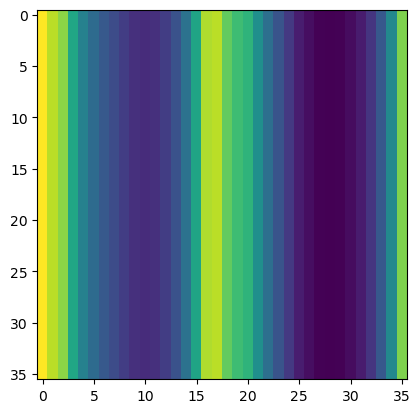

In [14]:
plt.imshow(ef_strength)
plt.show()